# DAY 5 - Train and Compare 3 Models

## What we do today:
1. Train Random Forest model
2. Train XGBoost model
3. Handle class imbalance properly
4. Compare all models in MLflow
5. Pick the best model

## Our benchmark to beat from Day 4:
Logistic Regression Recall = 0.759

Run each cell one by one using Shift+Enter

## CELL 1 - Import Everything
Loading all libraries needed for advanced models.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

os.makedirs('docs', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Connect to same MLflow experiment from Day 4
mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('churn-prediction')

print('All libraries loaded!')
print()
print('New models today:')
print('  RandomForestClassifier - many decision trees voting together')
print('  XGBClassifier          - powerful gradient boosting model')

2026/03/17 13:16:25 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.


All libraries loaded!

New models today:
  RandomForestClassifier - many decision trees voting together
  XGBClassifier          - powerful gradient boosting model


## CELL 2 - Load Data and Create Train/Test Split
Same split as Day 4. Always use the same split for fair comparison.

In [25]:
df = pd.read_csv('data/processed/churn_clean.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

split_point = int(len(df) * 0.80)
X_train = X.iloc[:split_point]
X_test  = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test  = y.iloc[split_point:]

# Scale for Logistic Regression comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Data loaded: {len(df):,} total customers')
print(f'Train set  : {len(X_train):,} customers')
print(f'Test set   : {len(X_test):,} customers')
print()
print(f'Features   : {X.shape[1]}')
print(f'Churn rate in test: {y_test.mean()*100:.1f}%')

# Helper function to evaluate any model
def evaluate_model(name, y_true, y_pred, y_prob):
    metrics = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'auc'      : roc_auc_score(y_true, y_prob)
    }
    print(f'--- {name} ---')
    print(f'  Accuracy  : {metrics["accuracy"]:.3f}')
    print(f'  Precision : {metrics["precision"]:.3f}')
    print(f'  Recall    : {metrics["recall"]:.3f}  <- most important!')
    print(f'  F1 Score  : {metrics["f1"]:.3f}')
    print(f'  AUC ROC   : {metrics["auc"]:.3f}')
    return metrics

print()
print('Ready to train models!')

Data loaded: 7,043 total customers
Train set  : 5,634 customers
Test set   : 1,409 customers

Features   : 26
Churn rate in test: 27.0%

Ready to train models!


## CELL 3 - Understand Class Imbalance Problem
Our data has 73% stayed and 27% churned.
Without fixing this, model will be lazy and predict No most of the time.
We need to tell the model: pay more attention to churners!

In [26]:
stayed_count  = (y_train == 0).sum()
churned_count = (y_train == 1).sum()
ratio = stayed_count / churned_count

print('=== CLASS IMBALANCE IN TRAINING DATA ===')
print()
print(f'  Stayed  (0): {stayed_count:,} customers')
print(f'  Churned (1): {churned_count:,} customers')
print(f'  Ratio       : {ratio:.1f}x more stayed than churned')
print()
print('HOW WE FIX IT:')
print()
print('Method 1: class_weight=balanced')
print('  Tell the model: each churner counts 2.7x more than non-churner')
print('  Used in: Logistic Regression, Random Forest')
print()
print('Method 2: scale_pos_weight in XGBoost')
print(f'  Set scale_pos_weight = {ratio:.0f} (the imbalance ratio)')
print('  XGBoost specific way to handle imbalance')
print()
print('Both methods tell the model: missing a churner is more costly!')

=== CLASS IMBALANCE IN TRAINING DATA ===

  Stayed  (0): 4,146 customers
  Churned (1): 1,488 customers
  Ratio       : 2.8x more stayed than churned

HOW WE FIX IT:

Method 1: class_weight=balanced
  Tell the model: each churner counts 2.7x more than non-churner
  Used in: Logistic Regression, Random Forest

Method 2: scale_pos_weight in XGBoost
  Set scale_pos_weight = 3 (the imbalance ratio)
  XGBoost specific way to handle imbalance

Both methods tell the model: missing a churner is more costly!


## CELL 4 - Model 1: Random Forest
Random Forest = 100 decision trees all voting together.
Each tree learns slightly different patterns.
Final prediction = majority vote of all 100 trees.
Very powerful and hard to overfit.

In [27]:
print('Training Random Forest...')
print('(This may take 10-20 seconds)')
print()

with mlflow.start_run(run_name='RandomForest'):

    rf = RandomForestClassifier(
        n_estimators=100,        # 100 trees voting together
        max_depth=10,            # trees can be at most 10 levels deep
        min_samples_leaf=5,      # each leaf needs at least 5 samples
        class_weight='balanced', # fix class imbalance
        random_state=42,         # reproducible results
        n_jobs=-1                # use all CPU cores for speed
    )

    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]

    rf_metrics = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)

    # Log everything to MLflow
    mlflow.log_metrics(rf_metrics)
    mlflow.log_param('model_type', 'RandomForest')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('max_depth', 10)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.sklearn.log_model(rf, 'random_forest_model')

print()
print('Random Forest training complete!')
print(f'Baseline recall was 0.759')
print(f'Random Forest recall: {rf_metrics["recall"]:.3f}')
if rf_metrics['recall'] > 0.759:
    print('BEAT THE BASELINE!')
else:
    print('Did not beat baseline yet - XGBoost might do better!')

Training Random Forest...
(This may take 10-20 seconds)



2026/03/17 13:16:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/17 13:16:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


--- Random Forest ---
  Accuracy  : 0.779
  Precision : 0.574
  Recall    : 0.717  <- most important!
  F1 Score  : 0.637
  AUC ROC   : 0.845

Random Forest training complete!
Baseline recall was 0.759
Random Forest recall: 0.717
Did not beat baseline yet - XGBoost might do better!


## CELL 5 - Model 2: XGBoost
XGBoost = Extreme Gradient Boosting.
Builds trees one by one where each tree fixes mistakes of previous tree.
Currently one of the most powerful models for tabular data.
Used in most winning Kaggle competitions.

In [28]:
stayed_count  = (y_train == 0).sum()
churned_count = (y_train == 1).sum()
scale_weight  = stayed_count / churned_count

print('Training XGBoost...')
print('(This may take 15-30 seconds)')
print()

with mlflow.start_run(run_name='XGBoost'):

    xgb = XGBClassifier(
        n_estimators=200,              # 200 trees
        max_depth=6,                   # tree depth
        learning_rate=0.05,            # how fast it learns
        scale_pos_weight=scale_weight, # fix class imbalance
        subsample=0.8,                 # use 80% of data per tree
        colsample_bytree=0.8,          # use 80% of features per tree
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )

    xgb.fit(X_train, y_train)

    y_pred_xgb = xgb.predict(X_test)
    y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

    xgb_metrics = evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)

    mlflow.log_metrics(xgb_metrics)
    mlflow.log_param('model_type', 'XGBoost')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('learning_rate', 0.05)
    mlflow.log_param('scale_pos_weight', round(scale_weight, 2))
    mlflow.sklearn.log_model(xgb, 'xgboost_model')

print()
print('XGBoost training complete!')
print(f'Baseline recall was : 0.759')
print(f'Random Forest recall: {rf_metrics["recall"]:.3f}')
print(f'XGBoost recall      : {xgb_metrics["recall"]:.3f}')

Training XGBoost...
(This may take 15-30 seconds)

--- XGBoost ---
  Accuracy  : 0.767
  Precision : 0.555
  Recall    : 0.701  <- most important!
  F1 Score  : 0.619
  AUC ROC   : 0.838


2026/03/17 13:16:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/17 13:16:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBoost training complete!
Baseline recall was : 0.759
Random Forest recall: 0.717
XGBoost recall      : 0.701


## CELL 6 - Full Comparison Table
Compare all 4 models side by side.
This exact table goes into your README.

In [29]:
# Retrain Logistic Regression for fair comparison
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
lr_metrics = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)

print()

# Build comparison table
results = pd.DataFrame([
    {'Model': 'Logistic Regression', **lr_metrics},
    {'Model': 'Random Forest',       **rf_metrics},
    {'Model': 'XGBoost',             **xgb_metrics}
])

results = results.round(3)
results = results.sort_values('recall', ascending=False)

print()
print('=== FULL MODEL COMPARISON ===')
print()
print(results.to_string(index=False))
print()

best_model_name = results.iloc[0]['Model']
best_recall     = results.iloc[0]['recall']
best_f1         = results.iloc[0]['f1']
best_auc        = results.iloc[0]['auc']

print(f'WINNER: {best_model_name}')
print(f'  Recall  : {best_recall:.3f}')
print(f'  F1 Score: {best_f1:.3f}')
print(f'  AUC ROC : {best_auc:.3f}')

# Save table
results.to_csv('docs/model_comparison.csv', index=False)
print()
print('Table saved to docs/model_comparison.csv')

--- Logistic Regression ---
  Accuracy  : 0.746
  Precision : 0.521
  Recall    : 0.759  <- most important!
  F1 Score  : 0.618
  AUC ROC   : 0.844


=== FULL MODEL COMPARISON ===

              Model  accuracy  precision  recall    f1   auc
Logistic Regression     0.746      0.521   0.759 0.618 0.844
      Random Forest     0.779      0.574   0.717 0.637 0.845
            XGBoost     0.767      0.555   0.701 0.619 0.838

WINNER: Logistic Regression
  Recall  : 0.759
  F1 Score: 0.618
  AUC ROC : 0.844

Table saved to docs/model_comparison.csv


## CELL 7 - Visual Comparison Chart
Bar chart comparing all models on all metrics.
This is the chart that goes in your README and impresses recruiters.

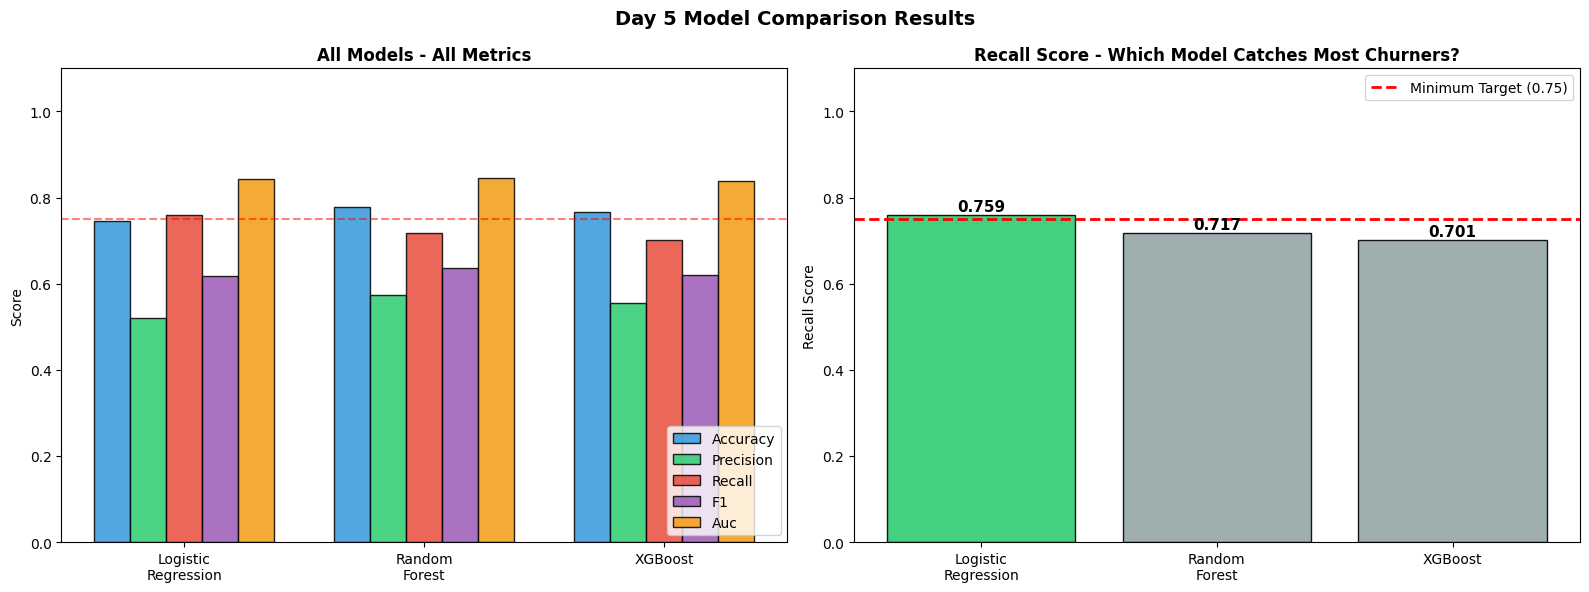

Chart saved to docs/model_comparison_chart.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models      = results['Model'].tolist()
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'auc']
colors       = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
x            = np.arange(len(models))
width        = 0.15

for i, (metric, color) in enumerate(zip(metrics_list, colors)):
    offset = (i - 2) * width
    bars = axes[0].bar(x + offset, results[metric], width,
                       label=metric.capitalize(), color=color,
                       alpha=0.85, edgecolor='black')

axes[0].set_title('All Models - All Metrics', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Logistic\nRegression', 'Random\nForest', 'XGBoost'])
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Target')

# Recall focused comparison
recall_values = results['recall'].tolist()
bar_colors    = ['#2ecc71' if v == max(recall_values) else '#95a5a6'
                 for v in recall_values]
bars = axes[1].bar(models, recall_values, color=bar_colors,
                   edgecolor='black', alpha=0.9)
axes[1].set_title('Recall Score - Which Model Catches Most Churners?',
                   fontweight='bold', fontsize=12)
axes[1].set_ylabel('Recall Score')
axes[1].set_xticklabels(['Logistic\nRegression', 'Random\nForest', 'XGBoost'])
axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=0.75, color='red', linestyle='--',
                linewidth=2, label='Minimum Target (0.75)')
axes[1].legend()
for bar, val in zip(bars, recall_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Day 5 Model Comparison Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to docs/model_comparison_chart.png')

## CELL 8 - ROC Curve
ROC Curve shows how good each model is at separating churners from non-churners.
The curve closer to the top-left corner is the better model.
AUC = area under this curve. Higher is better.

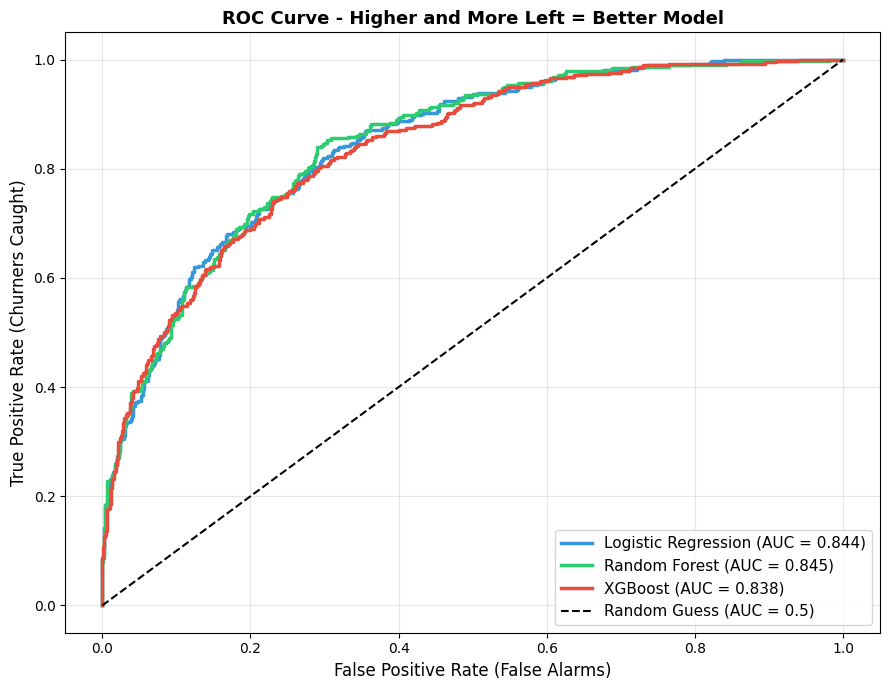

Chart saved to docs/roc_curve.png

HOW TO READ THIS:
  Top-left corner = perfect model
  Diagonal line   = random guessing (useless)
  Our models hug the top-left = they are working well!


In [31]:
plt.figure(figsize=(9, 7))

model_data = [
    ('Logistic Regression', y_prob_lr, '#3498db'),
    ('Random Forest',       y_prob_rf, '#2ecc71'),
    ('XGBoost',             y_prob_xgb, '#e74c3c')
]

for name, probs, color in model_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc          = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate (False Alarms)', fontsize=12)
plt.ylabel('True Positive Rate (Churners Caught)', fontsize=12)
plt.title('ROC Curve - Higher and More Left = Better Model', fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('docs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to docs/roc_curve.png')
print()
print('HOW TO READ THIS:')
print('  Top-left corner = perfect model')
print('  Diagonal line   = random guessing (useless)')
print('  Our models hug the top-left = they are working well!')

## CELL 9 - Pick the Best Model
Based on recall score, pick the winner.
Save it as the final model for Day 6 and 7.

In [32]:
# Compare recall scores
model_scores = {
    'Logistic Regression': (lr,  lr_metrics,  y_pred_lr,  y_prob_lr),
    'Random Forest'       : (rf,  rf_metrics,  y_pred_rf,  y_prob_rf),
    'XGBoost'             : (xgb, xgb_metrics, y_pred_xgb, y_prob_xgb)
}

# Find best by recall
best_name    = max(model_scores, key=lambda k: model_scores[k][1]['recall'])
best_model   = model_scores[best_name][0]
best_metrics = model_scores[best_name][1]

print('=== MODEL SELECTION DECISION ===')
print()
print('Why we choose by RECALL:')
print('  Missing a churner = losing a customer = losing revenue')
print('  So catching more churners is our top priority')
print()
print(f'WINNER: {best_name}')
print()
print('Scores:')
for metric, value in best_metrics.items():
    print(f'  {metric:<12}: {value:.3f}')
print()

# Save the best model
MODEL_PATH = 'models/churn_model.pkl'
joblib.dump(best_model, MODEL_PATH)

# Save scaler if best model is logistic regression
if best_name == 'Logistic Regression':
    joblib.dump(scaler, 'models/scaler.pkl')
    print('Scaler also saved (needed for Logistic Regression)')

# Save feature names for later use
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'models/feature_names.pkl')

print(f'Best model saved to: {MODEL_PATH}')
print(f'Feature names saved to: models/feature_names.pkl')
print()
print('This model will be used in:')
print('  Day 6 - SHAP explanations and error analysis')
print('  Day 7 - Streamlit dashboard predictions')

=== MODEL SELECTION DECISION ===

Why we choose by RECALL:
  Missing a churner = losing a customer = losing revenue
  So catching more churners is our top priority

WINNER: Logistic Regression

Scores:
  accuracy    : 0.746
  precision   : 0.521
  recall      : 0.759
  f1          : 0.618
  auc         : 0.844

Scaler also saved (needed for Logistic Regression)
Best model saved to: models/churn_model.pkl
Feature names saved to: models/feature_names.pkl

This model will be used in:
  Day 6 - SHAP explanations and error analysis
  Day 7 - Streamlit dashboard predictions


In [33]:
print('================================================')
print('DAY 5 COMPLETE!')
print('================================================')
print()
print('What you did today:')
print('  Understood class imbalance problem')
print('  Trained Random Forest (100 trees)')
print('  Trained XGBoost (gradient boosting)')
print('  Compared all 3 models in MLflow')
print('  Drew ROC curves for all models')
print('  Selected best model by recall score')
print('  Saved best model to models/churn_model.pkl')
print()
print('Files created:')
print('  models/churn_model.pkl       <- your trained model')
print('  models/feature_names.pkl     <- column names')
print('  docs/model_comparison_chart.png')
print('  docs/model_comparison.csv')
print('  docs/roc_curve.png')
print()
print('NEXT: Day 6 - SHAP Explanations + Error Analysis')

DAY 5 COMPLETE!

What you did today:
  Understood class imbalance problem
  Trained Random Forest (100 trees)
  Trained XGBoost (gradient boosting)
  Compared all 3 models in MLflow
  Drew ROC curves for all models
  Selected best model by recall score
  Saved best model to models/churn_model.pkl

Files created:
  models/churn_model.pkl       <- your trained model
  models/feature_names.pkl     <- column names
  docs/model_comparison_chart.png
  docs/model_comparison.csv
  docs/roc_curve.png

NEXT: Day 6 - SHAP Explanations + Error Analysis
